In [1]:
import torch
import time
import torch.nn as nn

from neuromancer.loggers import BasicLogger
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import ode, integrators

from SparseDPC.src.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.src.data.getdata import get_data, get_policy_data
from SparseDPC.src.trainer.trainer import SparseTrainer
from SparseDPC.src.utils.integrator import OneElementEulerIntegrator


torch.manual_seed(86)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device = torch.device('cpu')


In [2]:
# ground truth system model
gt_model = psl.nonautonomous.VanDerPolControl()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = -5.
umax = 5.
xmin = -5.
xmax = 5.



In [13]:
fx_models = [fx_library(i, nx=nx, nu=nu, seed=5, device=device,
                           max_degree=4, add_sqrt=False, add_u_prod=True) for i in range(nx)]
for fx in fx_models:
    print(fx)

dx0/dt = 0.266*x0 + -0.113*x1 + 0.230*x0*x1 + -0.314*x1^2 + 0.420*x0^3 + -0.050*x0^2*x1 + -0.485*x0*x1^2 + 0.104*x1^3 + -0.171*x0^4 + 0.105*x0^3*x1 + -0.199*x0^2*x1^2 + -0.383*x0*x1^3 + 0.012*x1^4 + 0.454*u_0 + 0.440*x0*u_0 + -0.268*x1*u_0 

dx1/dt = 0.266*x1 + -0.113*x0 + 0.230*x0^2 + -0.314*x0*x1 + 0.420*x0^3 + -0.050*x0^2*x1 + -0.485*x0*x1^2 + 0.104*x1^3 + -0.171*x0^4 + 0.105*x0^3*x1 + -0.199*x0^2*x1^2 + -0.383*x0*x1^3 + 0.012*x1^4 + 0.454*u_0 + 0.440*x0*u_0 + -0.268*x1*u_0 



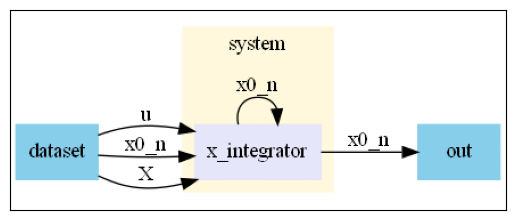

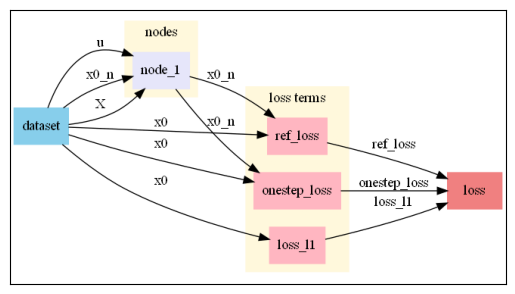

None
epoch: 0	train_loss: 27.81376	dev_loss: 2.04516	eltime:  1.11402
epoch: 100	train_loss: 0.06070	dev_loss: 0.04002	eltime:  20.25699
epoch: 200	train_loss: 0.01450	dev_loss: 0.02277	eltime:  39.31602


In [ ]:
for i in range(nx):

    nsim = 2000   # number of simulation steps in the dataset
    nsteps = 2  # number of prediction horizon steps in the loss function
    bs = 100     # minibatching batch size
    train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

    integrator_x = OneElementEulerIntegrator(fx_models[i], h=ts)
    integrator_node_x = Node(integrator_x, ['X', f'x{i}_n', 'u'], [f'x{i}_n'], name="x_integrator")
    dynamics_model_x = System([integrator_node_x])

    dynamics_model_x.show()

    x = variable(f"x{i}")
    x_hat = variable(f'x{i}_n')[:, :-1, :]

    # Loss
    onestep_loss_x = 1.0 * ((x_hat[:, 1, :] == x[:, 1, :])^ 2)
    onestep_loss_x.name = "onestep_loss"

    reference_loss_x = 5. *((x_hat == x) ^ 2)
    reference_loss_x.name = "ref_loss"

    # Sparsity constraint
    l1_x = variable([x], lambda x: torch.norm(list(fx_models[i].parameters())[0], p=1))
    loss_l1_x = 1e-7 * (l1_x == 0)
    loss_l1_x.name = "loss_l1"

    objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
    loss_x = PenaltyLoss(objectives_x, [])
    problem_x = Problem([dynamics_model_x], loss_x)
    problem_x.show()

    lr = 1e-3
    optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

    logger = BasicLogger(args=None, savedir='test', verbosity=100,
                    stdout=['dev_loss', 'train_loss'])
    epochs=5000

    trainer_x = SparseTrainer(
        problem      = problem_x,
        fx_models  = [fx_models[i]],      # list of SINDy models
        lr           = 1e-3,
        train_data=None,
        test_data=None,
        optimizers=[optimizer_x],
        epochs=epochs,
        train_metric='train_loss',
        eval_metric='dev_loss',
        logger=logger,
        device=device,
        threshold=0.1,
        prune_every=500,
        warmup=300,
        patience=50,
        threshold_mult=1.05,
        )
    for _ in range(1):

        train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)
        trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
        trainer_x.problem = problem_x  # Keep the problem consistent

        # Train control policy
        best_model = trainer_x.train()


        trainer_x.model.load_state_dict(best_model)

        # Update step size
        nsteps *= 2
        # trainer.model.loss.objectives[2].weight *= 1.1
        dynamics_model_x.nsteps = nsteps

